# 🛰️ LAB: MODELADO DE ENLACES Y CLASIFICACIÓN DE SEÑALES EN TELECOMUNICACIONES ESPACIALES
**Cuaderno Técnico de Desafíos Avanzados: `practica_telecomunicaciones.ipynb`**

¡Bienvenidos, ingenieros y analistas del área de Telecomunicaciones Satelitales! El objetivo de este laboratorio práctico es aplicar redes neuronales artificiales para caracterizar los fenómenos electromagnéticos atmosféricos y automatizar la monitorización del espectro de RF mediante el reconocimiento autónomo de señales en órbita.

En los segmentos de enlace ascendente (Uplink) y descendente (Downlink), la dinámica del canal de comunicaciones introduce severas degradaciones. A lo largo de este cuaderno, utilizaremos **TensorFlow y Keras** para entrenar una red profunda que aprenda a modelar la atenuación no lineal provocada por la tasa de precipitación (Rain Fade) en bandas de alta frecuencia, y construiremos un clasificador multiclase capaz de identificar el tipo de modulación digital directamente desde los componentes en fase y cuadratura (I/Q) recibidos por la estación terrena.

---

### 🧱 NUESTRA HOJA DE RUTA DE INGENIERÍA

Para resolver con éxito cada uno de los desafíos planteados, deberás aplicar rigurosamente la secuencia de desarrollo estandarizada:

1. **FASE 0 (Canal de Datos):** Capturar la telemetría electromagnética o los vectores I/Q simulados por el instructor, auditando sus rangos y dispersión.
2. **ETAPA A (Definición Arquitectónica):** Instanciar la estructura secuencial de la red, evaluando la densidad de neuronas y las funciones de activación idóneas para el problema físico.
3. **ETAPA B (Compilación Matemática):** Configurar el optimizador (`Adam`), establecer su tasa de aprendizaje e implementar la función de pérdida matemática correcta.
4. **ETAPA C (Entrenamiento Dinámico):** Disparar el ciclo iterativo (`fit`) contrastando las curvas de aprendizaje frente a datos de validación independientes.
5. **EVALUACIÓN ANALÍTICA:** Validar las métricas operacionales de la IA frente a los estándares de telecomunicaciones internacionales.

---

### 🚨 DINÁMICA DEL LABORATORIO:
Completa el código faltante en los espacios señalados como **"TU TURNO DE ESCRIBIR CÓDIGO"**. Al finalizar cada reto, podrás contrastar tus resultados con la **Solución Maestra del Docente** desplegando la celda oculta. ¡Éxito analistas!

### problema 1: Modelado de Atenuación Exponencial por Desvanecimiento por Lluvia (Rain Fade)

**Contexto:** Al operar enlaces de telecomunicaciones satelitales en Bandas Ku y Ka, la hidrometeorología representa el principal factor de degradación. La absorción y dispersión electromagnética provocada por las gotas de lluvia genera una atenuación específica ($A$) en dB/km que responde de forma estrictamente no lineal y exponencial frente a la tasa de precipitación ($R$) en mm/h (según los modelos empíricos de la UIT-R P.838).

**Tu Objetivo:** Diseñar una Red Neuronal Profunda capaz de aproximar la curva empírica de pérdida en dB/km a partir de la tasa de precipitación en bruto, permitiendo automatizar los márgenes de enlace dinámicos de la estación terrena.

#### 📋 Guía de Implementación Paso a Paso:
1. **Fase 0 (Datos):** Ejecuta la celda del instructor para cargar el perfil electromagnético simulado en Banda Ka.
2. **Etapa A (Definir):** Instancia una red secuencial con capas ocultas profundas para modelar el crecimiento exponencial. Configura una primera capa oculta de **32 neuronas** con activación `relu`, una segunda capa oculta de **16 neuronas** con activación `relu`, y una neurona de salida lineal (`units=1`).
3. **Etapa B (Compilar):** Compila el modelo utilizando el optimizador `Adam` (learning rate de `0.005`) y la función de pérdida `mse`.
4. **Etapa C (Entrenar):** Entrena la red por **120 épocas** pasando los conjuntos de entrenamiento y validación.

In [1]:
# =====================================================================
# FASE 0: SIMULACIÓN DE CANAL ELECTROMAGNÉTICO (RAIN FADE EN BANDA Ka)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(44)

# Tasa de precipitación (0 a 100 mm/h - de llovizna a tormenta severa)
X_rain = np.random.uniform(0.0, 100.0, 250)
# Física UIT-R P.838: A = a * R^b (Para Banda Ka circular, aprox: a=0.15, b=1.05)
Y_attenuation = (0.15 * (X_rain ** 1.1)) + np.random.normal(0, 0.6, 250)
Y_attenuation = np.clip(Y_attenuation, 0.0, None) # Limitación física: No hay atenuación negativa

# Partición de datos (80% Train, 20% Val)
X_train_p1, X_val_p1 = X_rain[:200], X_rain[200:]
Y_train_p1, Y_val_p1 = Y_attenuation[:200], Y_attenuation[200:]

print("--> [Fase 0] Éxito: Curva empírica de degradación de RF en banda Ka cargada.")

--> [Fase 0] Éxito: Curva empírica de degradación de RF en banda Ka cargada.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


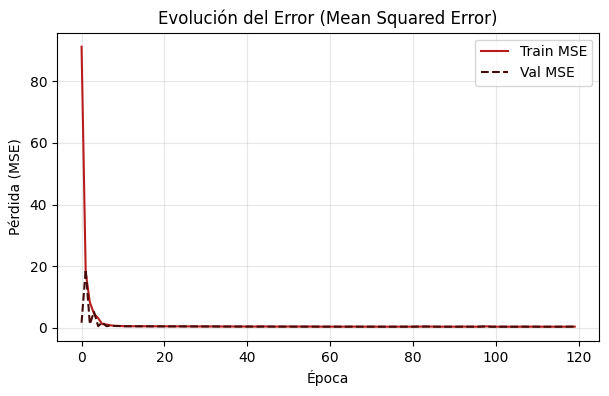

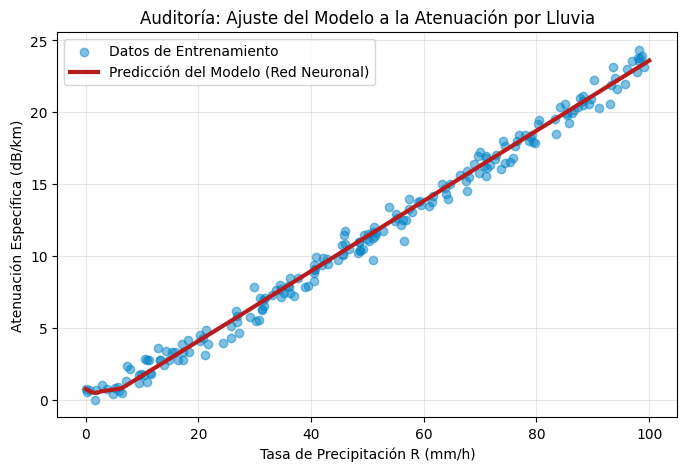

In [7]:
# @title Solución Oficial - Problema 1
# =====================================================================
# DESAFÍO 1: TU TURNO DE ESCRIBIR CÓDIGO (MODELADO DE CANAL DE RF)
# =====================================================================

# 1. ETAPA A: Define el modelo multicapa profundo con activaciones relu
model_p1 = keras.Sequential([
    keras.layers.Dense(units=32, activation='relu', input_shape=[1]),
    keras.layers.Dense(units=16, activation='relu'),
    keras.layers.Dense(units=1)
])

# 2. ETAPA B: Compila el modelo (Adam 0.005, Pérdida MSE)
model_p1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse')

# 3. ETAPA C: Entrena el modelo por 120 épocas
history_p1 = model_p1.fit(X_train_p1, Y_train_p1, epochs=120, validation_data=(X_val_p1, Y_val_p1), verbose=0)

# --- Visualización de métricas de entrenamiento ---
plt.figure(figsize=(7, 4))
plt.plot(history_p1.history['loss'], label='Train MSE', color='#b91c1c')
plt.plot(history_p1.history['val_loss'], label='Val MSE', linestyle='--', color='#450a0a')
plt.title('Evolución del Error (Mean Squared Error)')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Visualización del ajuste del modelo vs Datos Reales ---
plt.figure(figsize=(8, 5))
# Datos de entrenamiento originales
plt.scatter(X_train_p1, Y_train_p1, color='#0284c7', alpha=0.5, label='Datos de Entrenamiento')
# Curva de predicción del modelo
X_grid = np.linspace(0, 100, 200).reshape(-1, 1)
Y_pred = model_p1.predict(X_grid, verbose=0)
plt.plot(X_grid, Y_pred, color='#b91c1c', lw=3, label='Predicción del Modelo (Red Neuronal)')

plt.title("Auditoría: Ajuste del Modelo a la Atenuación por Lluvia")
plt.xlabel("Tasa de Precipitación R (mm/h)")
plt.ylabel("Atenuación Específica (dB/km)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### problema 2: Clasificación de Esquemas de Modulación mediante Vectores I/Q de Constelación

**Contexto:** Los receptores de las estaciones terrenas procesan señales digitales decodificando sus componentes de Fase ($I$) y Cuadratura ($Q$). Dependiendo del esquema programado en el módem del satélite, los vectores de amplitud distribuyen la energía en geometrías específicas. Monitorizar e identificar de forma ciega si una portadora es **BPSK (Clase 0)**, **QPSK (Clase 1)** o **8-PSK (Clase 2)** es vital para la gestión de interferencias y la radio definida por software (SDR).

**Tu Objetivo:** Desarrollar un clasificador multiclase que analice la magnitud de un vector bidimensional (I, Q) afectado por ruido térmico de fondo para diagnosticar instantáneamente el esquema de modulación de la portadora.

#### 📋 Guía de Implementación Paso a Paso:
1. **Fase 0 (Datos):** Ejecuta la celda del instructor. Obtendrás una matriz donde cada muestra combina las coordenadas $(I, Q)$ y sus etiquetas mapeadas en One-Hot encoding.
2. **Etapa A (Definir):** Instancia el modelo secuencial. Configura una capa oculta de **24 neuronas** con activación `relu`. Diseña la capa de salida con **3 neuronas** (una por modulación) combinadas con la función de activación **`'softmax'`** para calcular las fronteras de decisión geométricas.
3. **Etapa B (Compilar):** Compila la red neuronal utilizando el optimizador `Adam` (learning rate de `0.005`) y, debido a la codificación One-Hot de las categorías, la función de pérdida **`'categorical_crossentropy'`**.
4. **Etapa C (Entrenar):** Entrena el modelo clasificador por **150 épocas**.

In [3]:
# =====================================================================
# FASE 0: SIMULACIÓN DE COORDENADAS DE CONSTELACIÓN DIGITAL (I/Q)
# =====================================================================
np.random.seed(90)
N_simbolos = 100
ruido_canal = 0.18

# Clase 0: BPSK (2 puntos en el eje horizontal: +1 y -1)
bpsk_puntos = np.random.choice([-1.0, 1.0], N_simbolos)
bpsk_i = bpsk_puntos + np.random.normal(0, ruido_canal, N_simbolos)
bpsk_q = np.random.normal(0, ruido_canal, N_simbolos)

# Clase 1: QPSK (4 puntos en los cuadrantes: +/-0.707 en I y Q)
qpsk_fases = np.random.choice([np.pi/4, 3*np.pi/4, -np.pi/4, -3*np.pi/4], N_simbolos)
qpsk_i = np.cos(qpsk_fases) + np.random.normal(0, ruido_canal, N_simbolos)
qpsk_q = np.sin(qpsk_fases) + np.random.normal(0, ruido_canal, N_simbolos)

# Clase 2: 8-PSK (8 puntos distribuidos circularmente cada 45 grados)
psk8_fases = np.random.choice([i * np.pi / 4 for i in range(8)], N_simbolos)
psk8_i = np.cos(psk8_fases) + np.random.normal(0, ruido_canal, N_simbolos)
psk8_q = np.sin(psk8_fases) + np.random.normal(0, ruido_canal, N_simbolos)

# Agrupamiento de vectores de modulación
X_iq = np.vstack([
    np.column_stack((bpsk_i, bpsk_q)),
    np.column_stack((qpsk_i, qpsk_q)),
    np.column_stack((psk8_i, psk8_q))
])

labels_telecom = np.array([0]*N_simbolos + [1]*N_simbolos + [2]*N_simbolos)
Y_iq_onehot = keras.utils.to_categorical(labels_telecom, num_classes=3)

# Mezclado aleatorio completo del espectro
shuffler = np.arange(X_iq.shape[0])
np.random.shuffle(shuffler)
X_iq, Y_iq_onehot = X_iq[shuffler], Y_iq_onehot[shuffler]

# Partición Train/Val (80/20)
X_train_p2, X_val_p2 = X_iq[:240], X_iq[240:]
Y_train_p2, Y_val_p2 = Y_iq_onehot[:240], Y_iq_onehot[240:]

print("--> [Fase 0] Éxito: Símbolos de constelación I/Q mezclados en canal ruidoso [240 Train, 60 Val].")

--> [Fase 0] Éxito: Símbolos de constelación I/Q mezclados en canal ruidoso [240 Train, 60 Val].


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


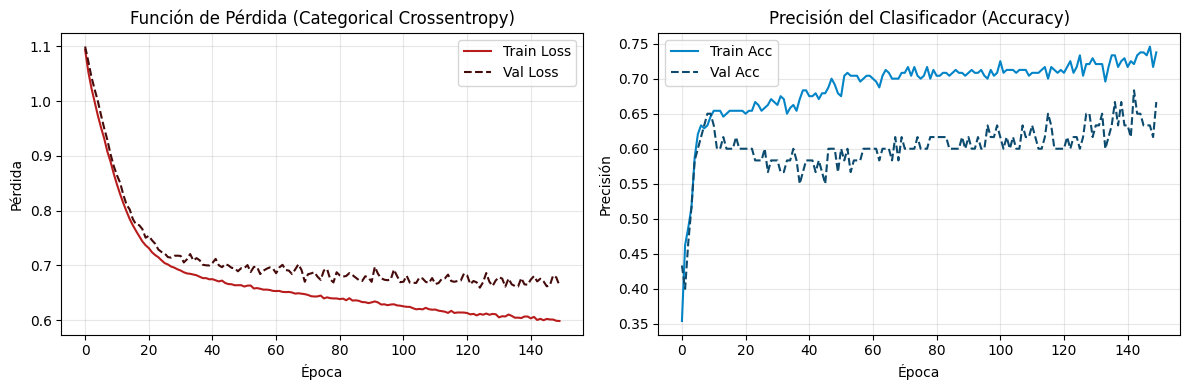

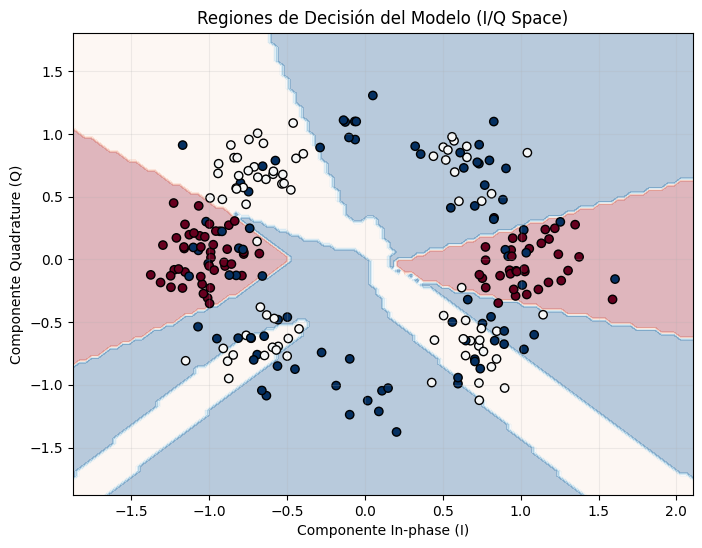

In [6]:
# @title Solución Oficial - Problema 2
# =====================================================================
# DESAFÍO 2: TU TURNO DE ESCRIBIR CÓDIGO (RECONOCIMIENTO DE MODULACIONES)
# =====================================================================

# 1. ETAPA A: Define el modelo clasificador (Entrada bidimensional, salida de 3 neuronas Softmax)
model_p2 = keras.Sequential([
    keras.layers.Dense(units=24, activation='relu', input_shape=[2]),
    keras.layers.Dense(units=3, activation='softmax')
])

# 2. ETAPA B: Compila el modelo (Adam 0.005, Categorical Crossentropy)
model_p2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='categorical_crossentropy', metrics=['accuracy'])

# 3. ETAPA C: Entrena el modelo por 150 épocas
history_p2 = model_p2.fit(X_train_p2, Y_train_p2, epochs=150, validation_data=(X_val_p2, Y_val_p2), verbose=0)

# --- Visualización de métricas de entrenamiento ---
# Corrección: Se define la figura y los ejes ax1, ax2 antes de usarlos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de Pérdida (Loss)
ax1.plot(history_p2.history['loss'], label='Train Loss', color='#b91c1c')
ax1.plot(history_p2.history['val_loss'], label='Val Loss', linestyle='--', color='#450a0a')
ax1.set_title('Función de Pérdida (Categorical Crossentropy)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica de Precisión (Accuracy)
ax2.plot(history_p2.history['accuracy'], label='Train Acc', color='#0284c7')
ax2.plot(history_p2.history['val_accuracy'], label='Val Acc', linestyle='--', color='#0c4a6e')
ax2.set_title('Precisión del Clasificador (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Visualización de Regiones de Decisión ---
x_min, x_max = X_train_p2[:, 0].min() - 0.5, X_train_p2[:, 0].max() + 0.5
y_min, y_max = X_train_p2[:, 1].min() - 0.5, X_train_p2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predicción sobre la malla
Z = model_p2.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_train_p2[:, 0], X_train_p2[:, 1], c=np.argmax(Y_train_p2, axis=1), edgecolors='k', cmap='RdBu', label='Datos Entrenamiento')
plt.title("Regiones de Decisión del Modelo (I/Q Space)")
plt.xlabel("Componente In-phase (I)")
plt.ylabel("Componente Quadrature (Q)")
plt.grid(True, alpha=0.2)
plt.show()